# Gene-Range Perturbation — Multi-Slide Analysis

In [1]:
%matplotlib inline
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'
TOP_N_PERTURB_VALUES = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000]

## 1. Load results across all slides

In [2]:
results_root = 'results/gene_range'
csvs = sorted(glob.glob(f'{results_root}/*/results.csv'))

dfs = []
for p in csvs:
    sid = int(Path(p).parent.name)
    df = pd.read_csv(p)
    df['slide_id'] = sid
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f'No results.csv files found under {results_root}/*/. Run perturb_gene_range.py first.')

all_df = pd.concat(dfs, ignore_index=True)
slide_ids = sorted(all_df['slide_id'].unique().tolist())
print(f'Loaded {len(dfs)} slide(s): {slide_ids}')
print(f'Total rows: {len(all_df)}')

# Convenience subsets
sweep_mean    = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].notna()].copy()
baseline_mean = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].isna()].copy()
ct_at_200     = all_df[(all_df['top_n_perturb'] == 200) & (all_df['cell_type'] != 'mean')].copy()
ct_baseline   = all_df[all_df['top_n_perturb'].isna() & (all_df['cell_type'] != 'mean')].copy()

sweep_mean['top_n_perturb'] = sweep_mean['top_n_perturb'].astype(int)

Loaded 5 slide(s): [210, 221, 231, 232, 242]
Total rows: 836


## 2. Summary plot with CI across slides

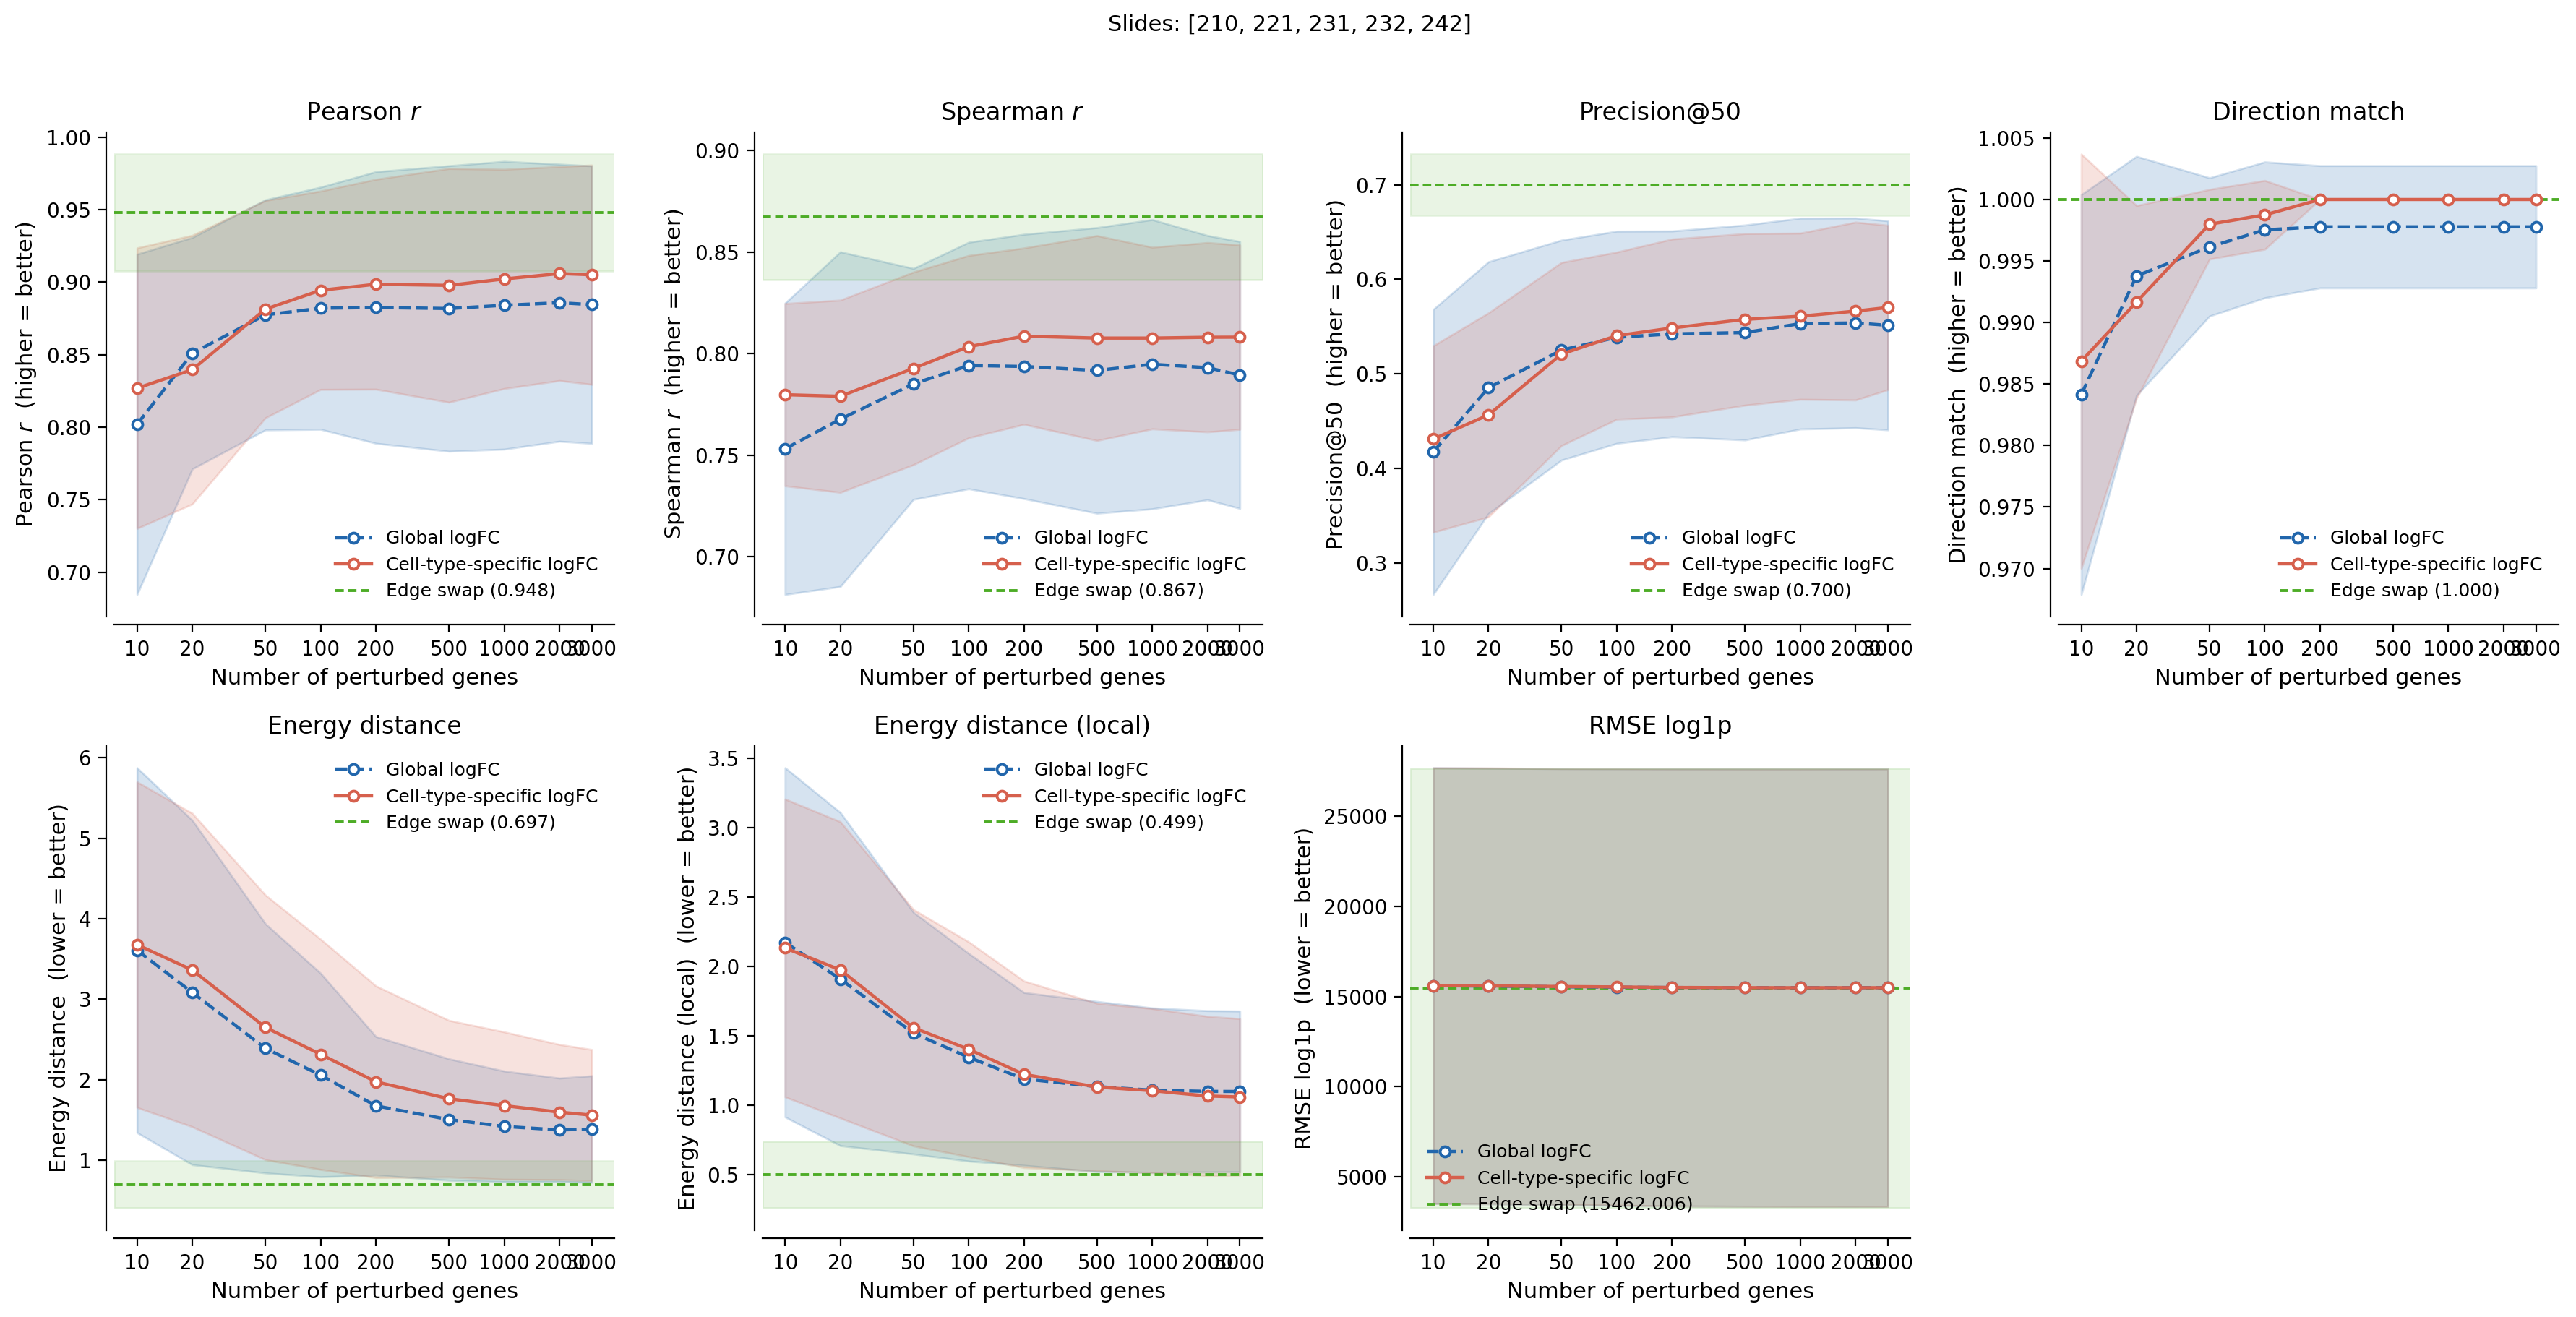

In [3]:
metrics_spec = [
    ('pearson_r',       'Pearson $r$',             True),
    ('spearman_r',      'Spearman $r$',             True),
    ('precision',       'Precision@50',             True),
    ('direction_match', 'Direction match',           True),
    ('edistance',       'Energy distance',           False),
    ('edistance_local', 'Energy distance (local)',   False),
    ('rmse_log1p',      'RMSE log1p',               False),
]

ncols = 4
nrows = -(-len(metrics_spec) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
axes = axes.flatten()

for i, (metric, ylabel, higher_better) in enumerate(metrics_spec):
    ax = axes[i]
    direction = 'higher = better' if higher_better else 'lower = better'

    for strategy, color, ls, label in [
        ('global', BLUE,   '--', 'Global logFC'),
        ('ctspec', ORANGE, '-',  'Cell-type-specific logFC'),
    ]:
        sub = sweep_mean[sweep_mean['strategy'] == strategy]
        grp = sub.groupby('top_n_perturb')[metric]
        means = grp.mean().reindex(TOP_N_PERTURB_VALUES)
        stds  = grp.std(ddof=1).reindex(TOP_N_PERTURB_VALUES).fillna(0)
        x = means.index.tolist()

        ax.fill_between(x, means - stds, means + stds, alpha=0.18, color=color)
        ax.plot(x, means, color=color, ls=ls, lw=1.6, marker='o', ms=5,
                markerfacecolor='white', markeredgewidth=1.4, label=label, zorder=3)

    # Edge-swap baseline
    bl = baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metric]
    bl_mean = bl.mean()
    bl_std  = bl.std(ddof=1) if len(bl) > 1 else 0.0
    ax.axhline(bl_mean, color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
               label=f'Edge swap ({bl_mean:.3f})', zorder=2)
    if bl_std > 0:
        ax.axhspan(bl_mean - bl_std, bl_mean + bl_std, alpha=0.12, color=GREEN, zorder=1)

    ax.set_xscale('log')
    ax.set_xticks(TOP_N_PERTURB_VALUES)
    ax.set_xticklabels([str(v) for v in TOP_N_PERTURB_VALUES], rotation=45, ha='right')
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('Number of perturbed genes')
    ax.set_ylabel(f'{ylabel}  ({direction})')
    ax.set_title(ylabel)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.legend(frameon=False, handlelength=2.0, fontsize=9)

for j in range(len(metrics_spec), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Slides: {slide_ids}', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

## 3. Per-cell-type boxplots at 200 genes

/tmp/ipykernel_1082557/3810763078.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_1082557/3810763078.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_1082557/3810763078.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_1082557/3810763078.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


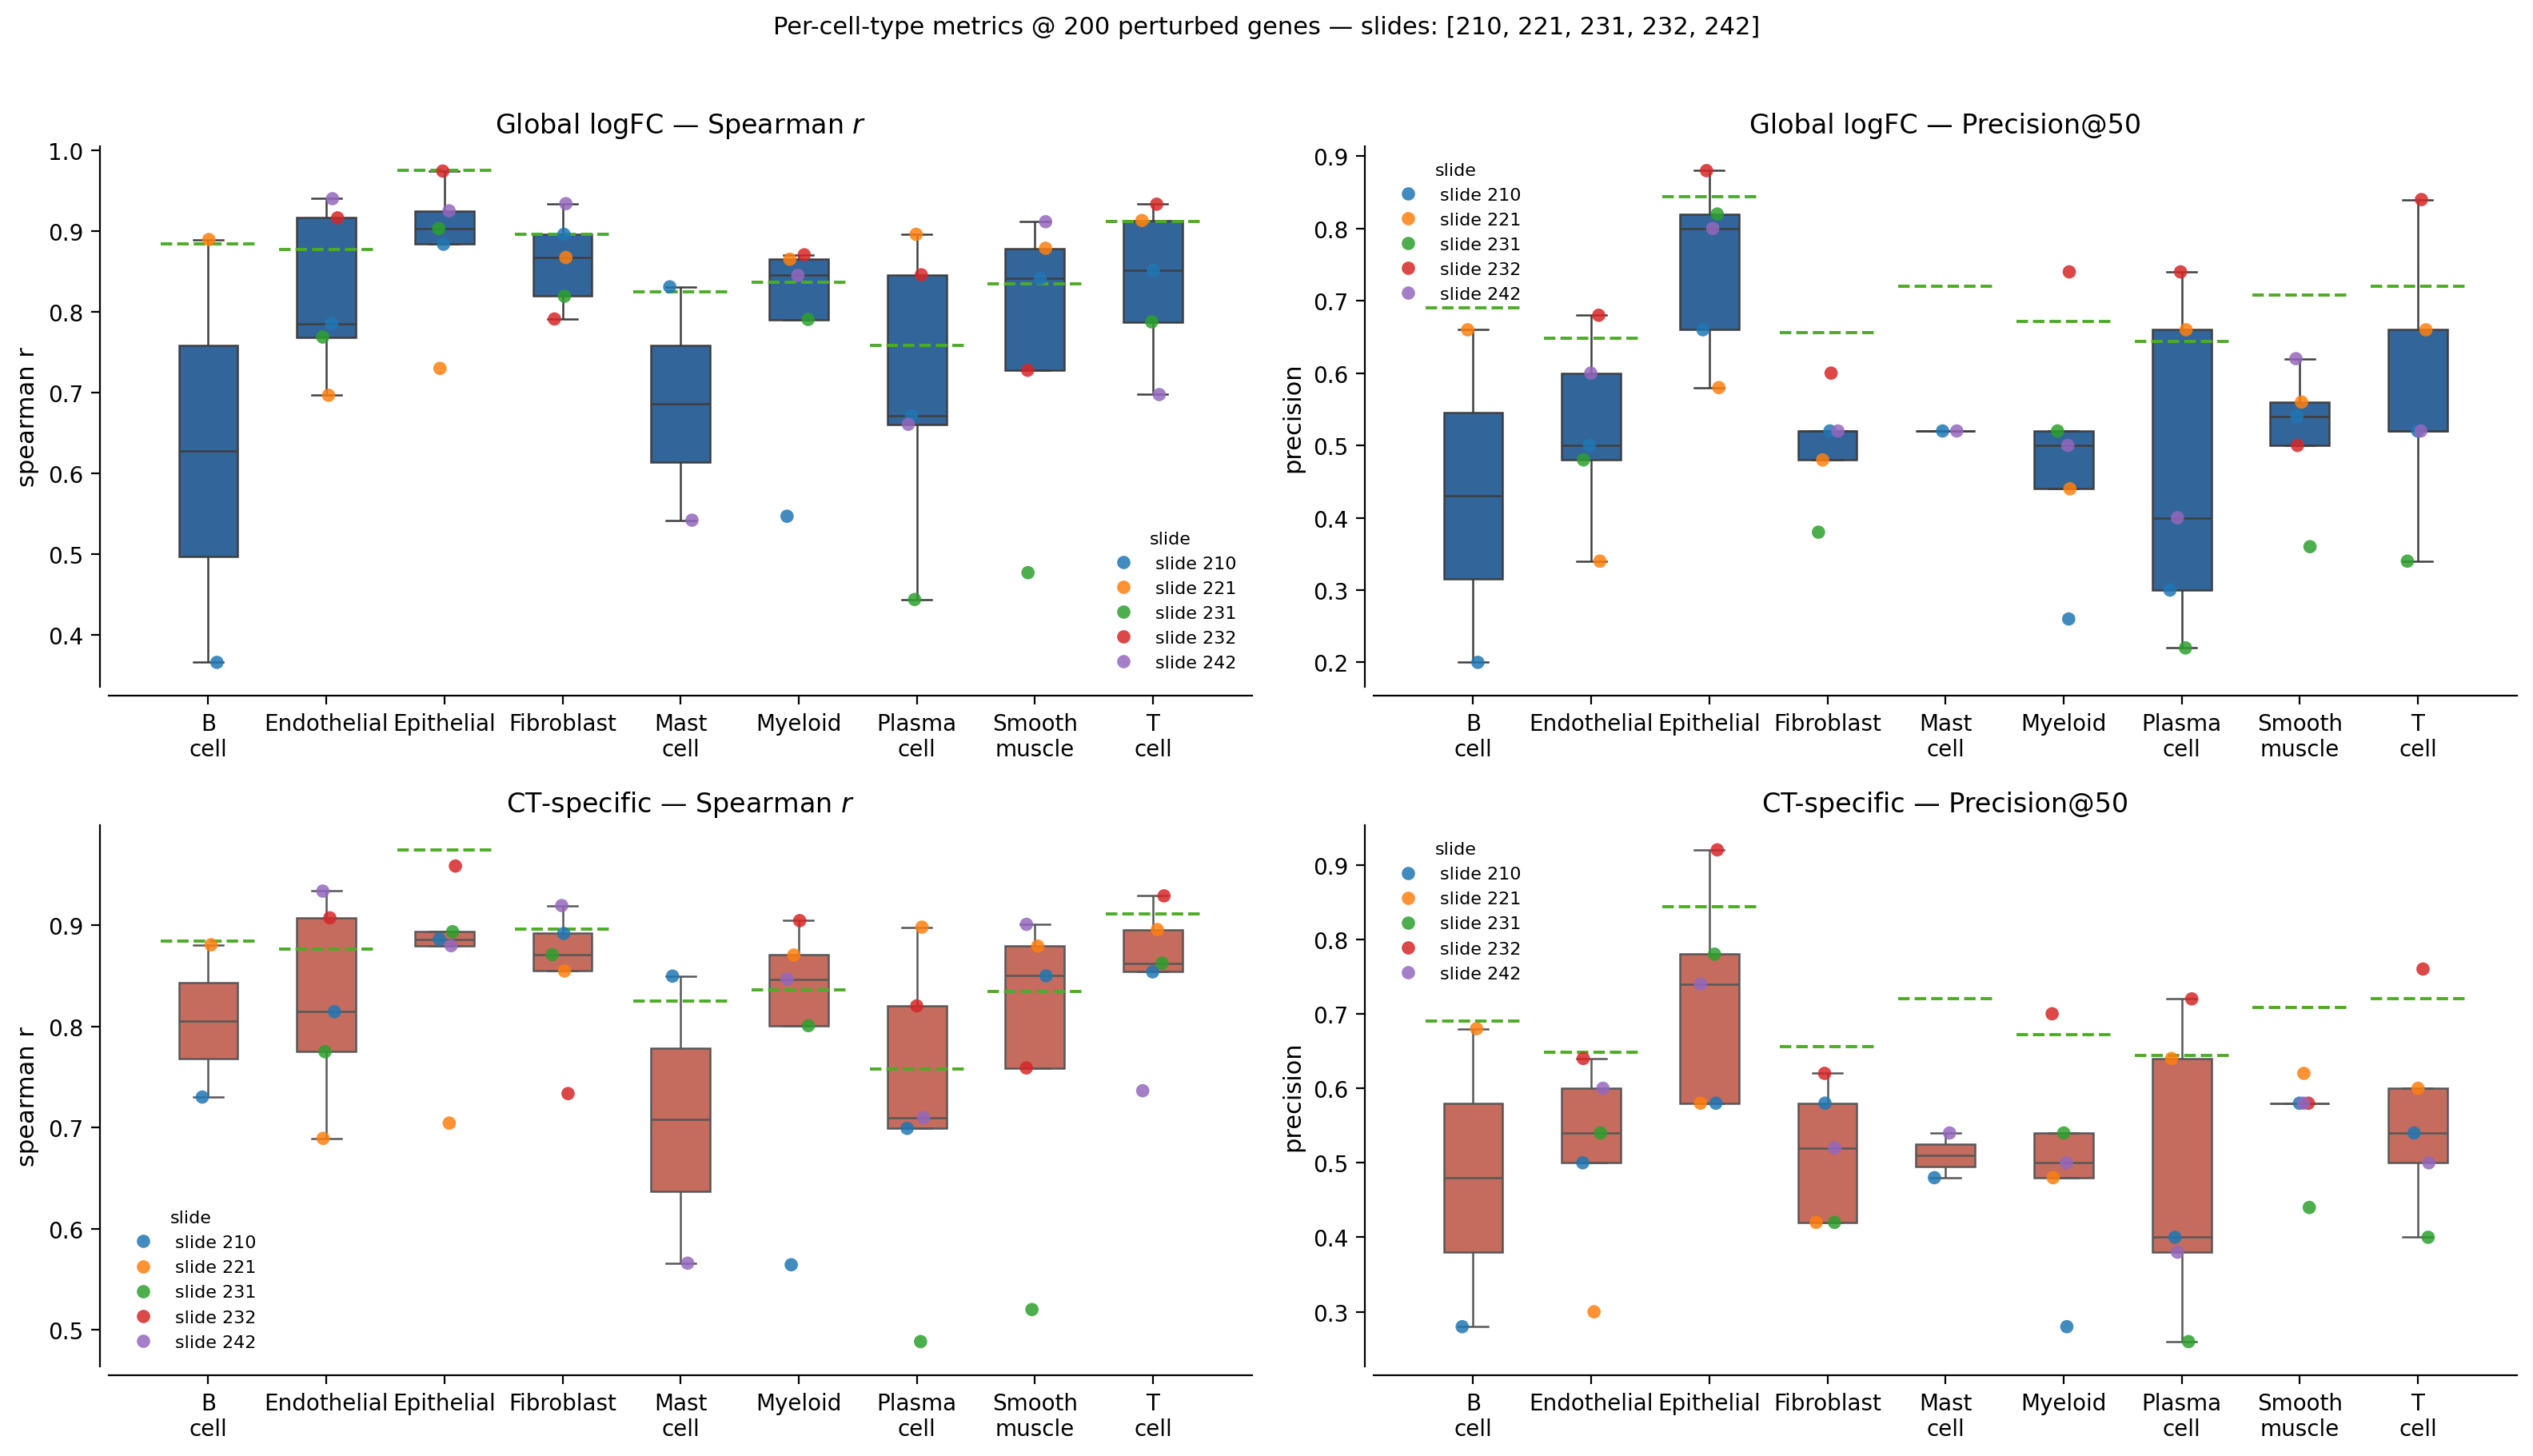

In [4]:
cell_types = sorted(ct_at_200['cell_type'].unique().tolist())

plot_specs = [
    ('global', 'spearman_r',  f'Global logFC — Spearman $r$',    BLUE),
    ('global', 'precision',   f'Global logFC — Precision@50',    BLUE),
    ('ctspec', 'spearman_r',  f'CT-specific — Spearman $r$',     ORANGE),
    ('ctspec', 'precision',   f'CT-specific — Precision@50',     ORANGE),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, (strategy, metric, title, color) in zip(axes.flatten(), plot_specs):
    subset = ct_at_200[ct_at_200['strategy'] == strategy]

    sns.boxplot(
        data=subset, x='cell_type', y=metric, order=cell_types,
        ax=ax, color=color, width=0.5, linewidth=0.9,
        flierprops=dict(marker='', markersize=0),
    )
    sns.stripplot(
        data=subset, x='cell_type', y=metric, order=cell_types,
        ax=ax, hue='slide_id', palette='tab10', dodge=False,
        size=6, alpha=0.85, zorder=4,
    )

    # Per-cell-type edge-swap baseline as short horizontal ticks
    bl_sub = ct_baseline[ct_baseline['strategy'] == 'edge_swap']
    for xi, ct in enumerate(cell_types):
        ct_bl = bl_sub[bl_sub['cell_type'] == ct][metric]
        if len(ct_bl) > 0:
            bl_val = ct_bl.mean()
            ax.hlines(bl_val, xi - 0.4, xi + 0.4,
                      colors=GREEN, linewidths=1.4, linestyles='--', zorder=3)

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_xticklabels(
        [ct.replace('_', '\n') for ct in cell_types],
        rotation=0, fontsize=9,
    )
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))

    handles, labels = ax.get_legend_handles_labels()
    # Only show slide_id legend entries (stripplot)
    slide_handles = [h for h, l in zip(handles, labels) if l.lstrip('-').isdigit()]
    slide_labels  = [l for l in labels if l.lstrip('-').isdigit()]
    if slide_handles:
        ax.legend(slide_handles, [f'slide {l}' for l in slide_labels],
                  frameon=False, fontsize=8, title='slide', title_fontsize=8)
    else:
        ax.get_legend().remove() if ax.get_legend() else None

fig.suptitle(f'Per-cell-type metrics @ 200 perturbed genes — slides: {slide_ids}',
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()